In [10]:
from spatialdata_io import xenium
import spatialdata as sd

## Load the Xenium output to a SpatialData object

**FFPE Human Prostate Adenocarcinoma with 5K Human Pan Tissue and Pathways Panel**

https://www.10xgenomics.com/datasets/xenium-prime-ffpe-human-prostate

In [ ]:
xenium_path = "/media/augusta/Xenium5K"
sdata = xenium(xenium_path)

INFO     reading /media/augusta/Xenium5K/cell_feature_matrix.h5                                                    


/tmp/ipykernel_37736/3993164536.py:2: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = xenium(xenium_path)
/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/spatialdata_io/_utils.py:48: UserWarning: The "cell_id" column in the cells metadata table does not match the "cell_id" column in the annotation table. This could be due to trying to read a new version that is not supported yet. Please report this issue.
  return f(*args, **kwargs)
/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/spatialdata_io/_utils.py:48: UserWarning: The cell_id column in the cell_labels_table does not match the cell_id column derived from the cell labels data. This could be due to trying to read a new version that is not supported yet. Please report this issue.
  return f(*args, **kwargs)


/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/tifffile/tifffile.py:8829: UserWarning: <tifffile.TiffPage 0 @16> reading array from closed file
  warnings.warn(
/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/tifffile/tifffile.py:8829: UserWarning: <tifffile.TiffPage 0 @16> reading array from closed file
  warnings.warn(
/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/tifffile/tifffile.py:8829: UserWarning: <tifffile.TiffPage 0 @16> reading array from closed file
  warnings.warn(
/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/tifffile/tifffile.py:8829: UserWarning: <tifffile.TiffPage 0 @16> reading array from closed file
  warnings.warn(
/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/tifffile/tifffile.py:8829: UserWarning: <tifffile.TiffPage 0 @16> reading array from closed file
  warnings.warn(


In [4]:
sdata

SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 30420, 54160), (4, 15210, 27080), (4, 7605, 13540), (4, 3802, 6770), (4, 1901, 3385)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (30420, 54160), (15210, 27080), (7605, 13540), (3802, 6770), (1901, 3385)
│     └── 'nucleus_labels': DataTree[yx] (30420, 54160), (15210, 27080), (7605, 13540), (3802, 6770), (1901, 3385)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (193000, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (193000, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (184853, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (193000, 5006)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (S

In [5]:
# Save the spatialdata object
sdata.write('data/Xenium5K_human_prostate.zarr')

INFO     The Zarr backing store has been changed from None the new file path: data/Xenium5K_human_prostate.zarr    


In [11]:
adata = sdata.table

/tmp/ipykernel_37736/2572188671.py:1: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  adata = sdata.table


In [13]:
adata

AnnData object with n_obs × n_vars = 193000 × 5006
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [21]:
import spatialdata_plot

INFO     Rasterizing image for faster rendering.                                                                   
INFO     Your image has 4 channels. Sampling categorical colors and using multichannel strategy 'stack' to render. 


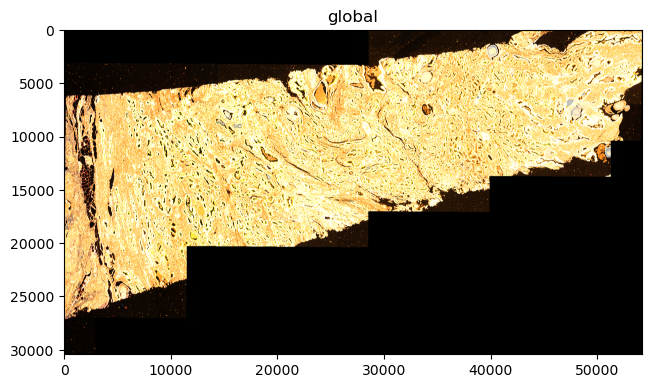

In [22]:
sdata.pl.render_images().pl.show()

INFO     Rasterizing image for faster rendering.                                                                   
INFO     Your image has 4 channels. Sampling categorical colors and using multichannel strategy 'stack' to render. 
INFO     Rasterizing image for faster rendering.                                                                   
INFO     Rasterizing image for faster rendering.                                                                   
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


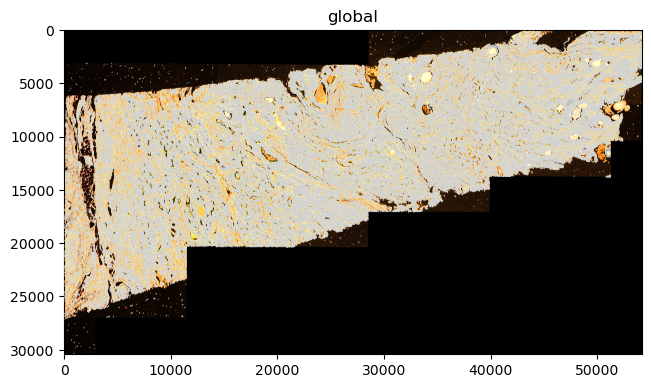

In [24]:
import spatialdata_plot

# Base tissue image
p = sdata.pl.render_images(element="morphology_focus")

# Add cell/nucleus labels (semi-transparent)
p = p.pl.render_labels(element="cell_labels", alpha=0.2)
p = p.pl.render_labels(element="nucleus_labels", alpha=0.2)

# Add cell boundaries on top
p = p.pl.render_shapes(element="cell_boundaries", linewidth=0.2)

# Show it
p.pl.show()

In [ ]:
p = p.pl.render_labels(element="nucleus_labels", alpha=0.2)
p.pl.show()

INFO     Rasterizing image for faster rendering.                                                                   
